In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def RK4(f, x, y, k, h):
    k1 = h * f(x, y, k)
    k2 = h * f(x + h/2, y + k1/2, k)
    k3 = h * f(x + h/2, y + k2/2, k)
    k4 = h * f(x + h, y + k3, k)
    return y + (k1 + 2 * k2 + 2 * k3 + k4)/6

def CallerRK4(f, xlim, yinit, k, N):
    x1, x2 = xlim
    xs = np.linspace(x1, x2, N)
    h = xs[1] - xs[0]
    ys = np.zeros((N, len(yinit)))
    ys[0] = np.array(yinit)
    for i in range(1, N):
        ys[i] = RK4(f, xs[i - 1], ys[i - 1], k, h)
    return xs, ys

In [3]:
def Secant(ks, f_ode, f_score, ybounds, tol, maxiter, xlim, N, L0):
    k1, k2 = ks
    it = 0
    print(f'[{k1}, {k2}]')
    while abs(f_score(k2, f_ode, ybounds, xlim, N, L0)) > tol and it < maxiter:
        f1 = f_score(k1, f_ode, ybounds, xlim, N, L0)
        f2 = f_score(k2, f_ode, ybounds, xlim, N, L0)
        k1, k2 = k2, (f2*k1 - f1*k2)/(f2 - f1)
        it += 1
        print(f"[[{it}]]\t[{k1:.4f}, {k2:.4f}]\t{f_score(k2, f_ode, ybounds, xlim, N, L0)}")
    if (it == maxiter):
        return it, None
    else:
        return it, k2

In [4]:
def Simpson13(y,h):
    store = y[0] + y[-1]
    for i in range(2,len(y)):
        if i % 2 == 0:
            store += 2 * y[i]
        else:
            store += 4 * y[i]
    return store * (h/3)

In [5]:
xlim = [-3.0, 3.0]
yinit = [0.0, 0.1]
ybounds = [0.0, 0.0]

L0 = 1.0
V0 = 100
N = 129
maxiter = 100
tol = 1e-8

In [6]:
def V(x):
    return -x*x

def f_ode(x, y, E):
    K = E - V(x)
    return np.array([y[1], -K * y[0]])

In [7]:
def f_score(E, f, ybound, xlim, N, L0):
    yinit1 = [ybound[0], 1e-2]
    yinit2 = [ybound[1], 1e-2]
    
    xs1, ys1 = CallerRK4(f, xlim, yinit1, E, N)
    xs2, ys2 = CallerRK4(f, xlim[-1::-1], yinit2, E, N)

    a1 = np.abs(xs1 + L0)
    a2 = np.abs(xs2 + L0)

    n1 = np.where(a1 == np.min(a1))[0][0]
    n2 = np.where(a2 == np.min(a2))[0][0]

    ys2 = ys1[n1][0] * ys2 / ys2[n2][0]

    return ys1[n1][1] - ys2[n2][1]

In [8]:
Es = np.linspace(0, 50, 1000)
scores = [f_score(E, f_ode, ybounds, xlim, N, L0) for E in Es]

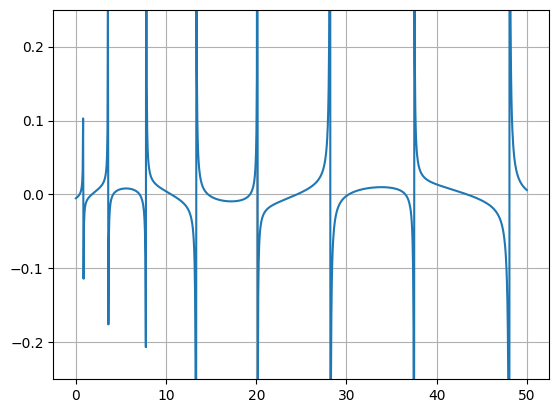

In [9]:
plt.plot(Es, scores)
plt.ylim(-0.25, 0.25)
plt.grid()
plt.show()

In [10]:
ks = [[0.5,1.5], [2.5,3.5], [4.5,5.5], [6.5,7.5], [9.5, 10.0], [14.5, 15], [18.5, 19.0]]
keigens = set([np.round(Secant(k0, f_ode, f_score, ybounds, tol, maxiter, xlim, N, L0)[1], 5).item() for k0 in ks])
print(keigens)

[0.5, 1.5]
[[1]]	[1.5000, 0.9438]	-0.026142606818641778
[[2]]	[0.9438, 1.5763]	-0.002176618344206431
[[3]]	[1.5763, 1.6338]	-0.0014874640865260007
[[4]]	[1.6338, 1.7577]	-9.380101323938704e-05
[[5]]	[1.7577, 1.7661]	-3.4911243597163157e-06
[[6]]	[1.7661, 1.7664]	-7.23369041229216e-09
[2.5, 3.5]
[[1]]	[3.5000, 2.3985]	0.006476344000900308
[[2]]	[2.3985, 2.3043]	0.005493980985417597
[[3]]	[2.3043, 1.7774]	0.00011860872298880655
[[4]]	[1.7774, 1.7658]	-6.6156323207530125e-06
[[5]]	[1.7658, 1.7664]	1.6999934994324332e-08
[[6]]	[1.7664, 1.7664]	2.4636513532363957e-12
[4.5, 5.5]
[[1]]	[5.5000, 3.1313]	0.018442119683445515
[[2]]	[3.1313, 7.3769]	-0.009151646771500889
[[3]]	[7.3769, 5.9688]	0.007779937768651081
[[4]]	[5.9688, 6.6158]	0.005093427124346121
[[5]]	[6.6158, 7.8425]	0.19455563562889605
[[6]]	[7.8425, 6.5828]	0.005318206005207448
[[7]]	[6.5828, 6.5474]	0.005545570449585992
[[8]]	[6.5474, 7.4109]	-0.011004246511850302
[[9]]	[7.4109, 6.8368]	0.0031866234879130107
[[10]]	[6.8368, 6.9657

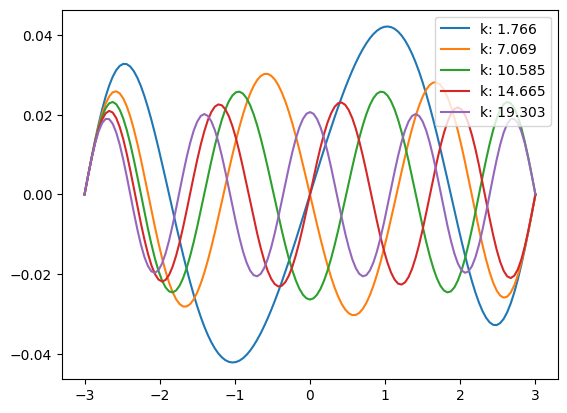

In [11]:
X = []
Y = []
for keigen in keigens:
    xs, ys = CallerRK4(f_ode, xlim, yinit, keigen, N)
    X.append(xs)
    Y.append(ys[:, 0]) # / (Simpson13(ys[:, 0], xs[1] - xs[0])))

for x, y, k in zip(X, Y, keigens):
    plt.plot(x, y, label=f'k: {k:.3f}')
plt.legend()
plt.show()